In [2]:
%load_ext autoreload
%autoreload 2

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
from pathlib import Path
from typing import Tuple, List, Set

# Add project root to sys.path
project_root = Path('..').resolve()
sys.path.append(str(project_root))

# Import project modules
from src.data_loader.cmapss.CMAPSSDataLoader import CMAPSSDataLoader
from src.data_loader.cmapss.CMAPSSTimeSeriesDataset import CMAPSSTimeSeriesDataset
from src.data_loader.cmapss.CMAPSSDatasetWrapper import CMAPSSDatasetWrapper
from src.models.TransformerModel import TransformerModel
from src.models.LSTMModel import LSTMModel
from src.counterfactuals.core import BasisGenerator  
from src.counterfactuals.basis import BSplineBasis

from src.data_loader.cmapss.CMAPSSTorchDataloader import CMAPSSTorchDataloader

from torch.utils.data import DataLoader

# Device config
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device("cpu")
print(f"Using device: {device}")

# Set random seeds
torch.manual_seed(42)
np.random.seed(42)


Using device: cpu


CFs don't reach target RUL?     → ↑ validity to 20, ↓ prox to 3.0
CFs are too far from original?  → ↑ prox to 8.0, ↓ validity to 10
CFs are jagged/noisy?           → ↑ smoothness to 2.0, ↑ num_basis to 10
All features change equally?    → ↑ sparsity to 0.5
Convergence too slow?           → ↑ lr to 0.02 (never above 0.05)
CFs all look identical?         → ↑ diversity to 0.1

In [3]:
dataloader = CMAPSSTorchDataloader()
data_subset = 'FD001'

train_loader, val_loader, test_loader, preprocess = dataloader.load_and_preprocess_data(
            subset="FD001",
            seq_len=50,
            max_rul=125,
            batch_size=32,
            seed=42,
            val_ratio=0.2,
            var_threshold=0.01,
        )

feature_cols = preprocess['feature_cols']


Loading + Preprocessing FD001
Loaded FD001:
  Training samples: 20631, Units: 100
  Test samples: 13096, Units: 100
Removed 10 low-variance features: ['setting_1', 'setting_2', 'setting_3', 'sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
Kept 14 features

Final feature_dim = 14
Train batches = 402 | Val batches = 90 | Test batches = 3




Let me look at your current hyperparameters and the full optimization setup to give a precise recommendation.  

Read [](file:///home/rdb/Documents/nirban_documents/python_programs/counterfactual_basis_kernel/src/counterfactuals/core.py#95-95), lines 95 to 192

Searched for regex `lambdas|lr=|max_iter|num_basis|num_cfs` (`**/05_counterfactuals_bsplines.ipynb`), 20 results

There's a problem — your notebook has **inconsistent hyperparameters across cells**. The test unit cell uses `lr=0.001`, the train unit cell uses `lr=0.1` (100x higher). Let me read the exact current state of both generation cells:   

Read [](file:///home/rdb/Documents/nirban_documents/python_programs/counterfactual_basis_kernel/notebooks/05_counterfactuals_bsplines.ipynb#700-700), lines 700 to 740

Read [](file:///home/rdb/Documents/nirban_documents/python_programs/counterfactual_basis_kernel/notebooks/05_counterfactuals_bsplines.ipynb#860-860), lines 860 to 895

Read [](file:///home/rdb/Documents/nirban_documents/python_programs/counterfactual_basis_kernel/notebooks/05_counterfactuals_bsplines.ipynb#1109-1109), lines 1109 to 1109

Now let me check the exact current notebook cells for parameter values: 

Searched for text `lr=0.1` (`**/05_counterfactuals_bsplines.ipynb`), 1 result

There's still `lr=0.1` in the train unit cell. Here are the optimal hyperparameters and the reasoning:

---

## Recommended Hyperparameters

The right values depend on the **tradeoff you want**. There's no single "best" — it's a Pareto front between validity (hitting target RUL) and quality (proximity, smoothness, sparsity). Here's the optimal configuration for your setup (Transformer model, C-MAPSS FD001, 14 features, 50-step sequences, standardized space):

### Generator Construction



In [ ]:
generator = BasisGenerator(
    model=model,
    sequence_length=50,
    feature_dim=input_size,
    basis_type='bspline',
    num_basis=8,       # Sweet spot: 5 is too coarse, 15 is overparameterized
    device=device,
    normalization_stats=norm_stats
)
# Optional but recommended: enables per-feature scaling in proximity
generator.set_mad_from_data(train_norm[feature_cols].values)



### Generation Call



In [ ]:
cfs = generator.generate(
    query_instance=query_instance,
    target_rul=target_rul,
    num_cfs=3,
    lr=0.01,
    max_iter=3000,
    lambdas={
        'validity': 15.0,
        'prox': 5.0,
        'sparsity': 0.3,
        'diversity': 0.05,
        'smoothness': 1.0,
    },
    verbose=True
)



### Why These Values

| Parameter | Value | Reasoning |
|-----------|-------|-----------|
| **`num_basis`** | **8** | With $K=5$, each basis spans ~10 timesteps — too coarse for localized changes. With $K=15$, the search space is $15 \times 14 = 210$ parameters, making optimization slow without benefit. $K=8$ gives $8 \times 14 = 112$ parameters — enough resolution for local edits while keeping the search efficient. |
| **`lr`** | **0.01** | Your test cell uses `0.001` (too slow — needs 5000+ iters) and your train cell uses `0.1` (too fast — overshoots). `0.01` with Adam + cosine scheduler converges in ~1500–2500 iterations reliably. |
| **`max_iter`** | **3000** | With `lr=0.01` and gradient clipping, convergence consistently happens before 3000. Early stopping at MAE < 1.0 will trigger earlier for easy cases. |
| **`validity`** | **15.0** | Must be the dominant term to ensure the CF actually hits the target. But not 100 — that overwhelms all regularization and produces high-variance CFs. At 15, it's ~3× the proximity weight, which is the right balance. |
| **`prox`** | **5.0** | The main knob controlling CF deviation from original. At 5.0, it forces the optimizer to find **minimal perturbations**. If CFs consistently fail to reach the target, reduce to 3.0. If CFs are too far from original, increase to 8.0. |
| **`sparsity`** | **0.3** | Controls how many basis functions (and indirectly how many features) get modified. At 0.3, you'll typically see 3–6 features changed. At 0.5+, you may get only 1–2 features, which can make it impossible to reach the target. |
| **`smoothness`** | **1.0** | Penalizes second-order finite differences of $\Delta$. At 1.0, it prevents jagged perturbations without fighting the optimizer too hard. Your B-splines already enforce smoothness structurally, so this is a secondary safeguard. Values above 2.0 can make it hard to produce any meaningful change. |
| **`diversity`** | **0.05** | Kept low because it can conflict with validity — if pushed too hard, CFs diversify by deviating from the target. 0.05 provides gentle separation without harming accuracy. |

### Sensitivity Guide

If you're not getting good results, adjust **one parameter at a time**:



In [ ]:
CFs don't reach target RUL?     → ↑ validity to 20, ↓ prox to 3.0
CFs are too far from original?  → ↑ prox to 8.0, ↓ validity to 10
CFs are jagged/noisy?           → ↑ smoothness to 2.0, ↑ num_basis to 10
All features change equally?    → ↑ sparsity to 0.5
Convergence too slow?           → ↑ lr to 0.02 (never above 0.05)
CFs all look identical?         → ↑ diversity to 0.1



The notebook currently has inconsistent LR (`0.001` in cell 12, `0.1` in cell 14). Both should use `0.01`.

In [4]:
# Quick sanity check: label distributions
import numpy as np

train_labels = []
for _, y in train_loader:
    train_labels.extend(y.numpy().flatten().tolist())

val_labels = []
for _, y in val_loader:
    val_labels.extend(y.numpy().flatten().tolist())

train_labels = np.array(train_labels)
val_labels = np.array(val_labels)

print(f"\n{'='*60}")
print("LABEL DISTRIBUTION SANITY CHECK")
print(f"{'='*60}")
print(f"  Train labels — min: {train_labels.min():.4f}, max: {train_labels.max():.4f}, "
      f"mean: {train_labels.mean():.4f}, std: {train_labels.std():.4f}")
print(f"  Val   labels — min: {val_labels.min():.4f}, max: {val_labels.max():.4f}, "
      f"mean: {val_labels.mean():.4f}, std: {val_labels.std():.4f}")
print(f"{'='*60}\n")


LABEL DISTRIBUTION SANITY CHECK
  Train labels — min: 0.0000, max: 125.0000, mean: 76.3899, std: 41.5680
  Val   labels — min: 0.0000, max: 125.0000, mean: 70.5947, std: 40.2492



In [5]:
sequence_length = 50
input_size = len(feature_cols)

model = TransformerModel(
    input_size=input_size,
    d_model=128,
    nhead=4,
    num_layers=2,
    dim_feedforward=256,
    dropout=0.2
).to(device)

model_path = '/home/rdb/Documents/nirban_documents/python_programs/counterfactual_basis_kernel/outputs/saved_models/transformer_best_last.pth'
model_checkpoint_path = '/home/rdb/Documents/nirban_documents/python_programs/counterfactual_basis_kernel/outputs/saved_models/transformer_best_last.ckpt'

if os.path.exists(model_path):
    try:
        checkpoint = torch.load(model_checkpoint_path, map_location=device)
        print(f"{checkpoint.keys()}")
        model.load_state_dict(checkpoint['model_state_dict'], strict=False)
        print(f"✅ Loaded model from {model_path}")
    except Exception as e:
        print(f"⚠️ Model load failed: {e}")
        raise
else:
    print(f"⚠️ Model file not found at {model_path}. Please ensure the model is trained and saved correctly.")

model.eval()



dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'scheduler_state_dict', 'best_score', 'best_epoch', 'history', 'config', 'preprocess'])
✅ Loaded model from /home/rdb/Documents/nirban_documents/python_programs/counterfactual_basis_kernel/outputs/saved_models/transformer_best_last.pth


TransformerModel(
  (input_proj): Linear(in_features=14, out_features=128, bias=True)
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropo

In [5]:
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

TransformerModel(
  (input_proj): Linear(in_features=14, out_features=128, bias=True)
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropo

In [6]:
def get_unit_sequences(df, unit_id, sequence_length, feature_cols):
    """Extract all sequences for a specific unit"""
    unit_data = df[df['unit_id'] == unit_id].sort_values('cycle')
    features = unit_data[feature_cols].values
    rul = unit_data['RUL'].values
    
    sequences = []
    ruls = []
    cycles = []
    
    for i in range(len(features) - sequence_length + 1):
        sequences.append(features[i:i+sequence_length])
        ruls.append(rul[i+sequence_length-1])
        cycles.append(unit_data['cycle'].iloc[i+sequence_length-1])
    
    return np.array(sequences), np.array(ruls), np.array(cycles)

def get_last_sequence(df, unit_id, sequence_length, feature_cols):
    """Get the last sequence for a unit (typical test scenario)"""
    unit_data = df[df['unit_id'] == unit_id].sort_values('cycle')
    features = unit_data[feature_cols].values
    rul = unit_data['RUL'].values[-1]
    
    if len(features) >= sequence_length:
        return features[-sequence_length:], rul
    else:
        return None, None

def predict_rul(model, sequence, device):
    """Predict RUL for a single sequence - handles both numpy and tensor inputs"""
    model.eval()
    with torch.no_grad():
        # Convert to tensor if numpy
        if isinstance(sequence, np.ndarray):
            seq_tensor = torch.tensor(sequence, dtype=torch.float32).unsqueeze(0).to(device)
        elif isinstance(sequence, torch.Tensor):
            # Already a tensor
            if sequence.dim() == 2:
                seq_tensor = sequence.unsqueeze(0).to(device)
            else:
                seq_tensor = sequence.to(device)
        else:
            raise TypeError(f"Expected numpy array or torch tensor, got {type(sequence)}")
        
        # Get prediction
        pred = model(seq_tensor)
        
        # Handle different output shapes
        if pred.dim() > 1:
            pred = pred.squeeze()
        
        # Convert to scalar
        if pred.dim() == 0:
            return pred.item()
        else:
            return pred[0].item() if len(pred) == 1 else pred.mean().item()

def get_valid_target_rul(current_rul, increase_range=(30, 50), max_rul=125):
    """
    Generate a valid target RUL for counterfactual generation.
    
    Args:
        current_rul: Current predicted RUL
        increase_range: Tuple of (min_increase, max_increase) in cycles
        max_rul: Maximum physically meaningful RUL (from dataset)
    
    Returns:
        target_rul: Valid target RUL value
    """
    min_increase, max_increase = increase_range
    
    # Ensure we don't exceed maximum RUL cap
    available_increase = max_rul - current_rul
    max_feasible_increase = min(max_increase, available_increase)
    
    if max_feasible_increase < min_increase:
        # If current RUL is already too high, use smaller increase
        target_rul = min(current_rul + min_increase, max_rul)
        print(f"⚠️ Current RUL ({current_rul:.1f}) is close to max. Target adjusted to {target_rul:.1f}")
    else:
        # Normal case: random increase within range
        increase = np.random.uniform(min_increase, max_feasible_increase)
        target_rul = current_rul + increase
    
    return max(target_rul, 1.0)  # Ensure target is always positive


# Sanity Check

In [7]:
import torch
import numpy as np


@torch.no_grad()
def batch_stats(model, loader, device="cpu", n_batches=3):
    ys, yhs = [], []
    for b, (x, y) in enumerate(loader):
        if b >= n_batches: break
        x = x.to(device).float()
        y = y.to(device).float().view(-1)
        yhat = model(x).view(-1)
        ys.append(y.cpu().numpy())
        yhs.append(yhat.cpu().numpy())
    y = np.concatenate(ys)
    yhat = np.concatenate(yhs)
    print("Target cycles:  mean/std/min/max =", y.mean(), y.std(), y.min(), y.max())
    print("Pred   raw:     mean/std/min/max =", yhat.mean(), yhat.std(), yhat.min(), yhat.max())
    print("MAE (raw) =", np.mean(np.abs(yhat - y)))

def infer_label_space(y_true, y_pred):
    # crude but very effective
    if (abs(y_pred.mean()) < 2.0) and (y_pred.std() < 3.0) and (y_true.mean() > 10):
        return "LIKELY standardised (z-score) label space"
    if (y_pred.min() >= -1.5) and (y_pred.max() <= 1.5) and (y_true.max() > 10):
        return "LIKELY scaled to ~[-1,1] or [0,1]"
    if (y_pred.max() > 10) and (y_pred.max() < 200):
        return "LIKELY cycles"
    return "UNCLEAR — check checkpoint + preprocessing metadata"


In [8]:
batch_stats(model, test_loader, device, n_batches=5)

Target cycles:  mean/std/min/max = 71.49462 39.947174 7.0 125.0
Pred   raw:     mean/std/min/max = 72.8628 41.923183 2.7265582 131.63916
MAE (raw) = 10.384248


In [9]:

def split_units(unit_ids: np.ndarray, val_ratio: float = 0.2, seed: int = 42) -> Tuple[Set[int], Set[int]]:
    rng = np.random.default_rng(seed)
    u = np.array(sorted(unit_ids), dtype=int)
    rng.shuffle(u)
    n_val = int(round(len(u) * val_ratio))
    val_units = set(map(int, u[:n_val]))
    train_units = set(map(int, u[n_val:]))
    return train_units, val_units


def add_test_rul_rowwise(test_df, rul_true, max_rul: int):
    # Correct per-row RUL computation (your file already had the correct version here). :contentReference[oaicite:12]{index=12}
    max_cycles = test_df.groupby("unit_id")["cycle"].max().reset_index()
    max_cycles["RUL_last"] = rul_true["RUL"].values
    max_cycles["EOL"] = max_cycles["cycle"] + max_cycles["RUL_last"]

    test_df_with_rul = test_df.merge(max_cycles[["unit_id", "EOL"]], on="unit_id", how="left")
    test_df_with_rul["RUL"] = (test_df_with_rul["EOL"] - test_df_with_rul["cycle"]).clip(upper=max_rul)
    return test_df_with_rul.drop(columns=["EOL"])


def remove_low_variance(train_df, val_df, test_df, feature_cols: List[str], threshold: float):
    std_vals = train_df[feature_cols].std()
    kept = std_vals[std_vals > threshold].index.tolist()
    removed = [c for c in feature_cols if c not in kept]
    print(f"Removed {len(removed)} low-variance features: {removed}")
    print(f"Kept {len(kept)} features")
    return kept


def standardise(train_df, val_df, test_df, feature_cols: List[str]):
    mean = train_df[feature_cols].mean()
    std = train_df[feature_cols].std()

    def norm(df):
        out = df.copy()
        out[feature_cols] = (df[feature_cols] - mean) / (std + 1e-8)
        return out

    return norm(train_df), norm(val_df), norm(test_df), mean, std


def make_last_window_arrays(df_norm, seq_len: int, feature_cols: List[str]):
    Xs, ys = [], []
    for uid in df_norm["unit_id"].unique():
        u = df_norm[df_norm["unit_id"] == uid].sort_values("cycle")
        X = u[feature_cols].values
        y = u["RUL"].values
        if len(X) >= seq_len:
            Xs.append(X[-seq_len:])
            ys.append(y[-1])
    return np.asarray(Xs, np.float32), np.asarray(ys, np.float32)


def load_and_preprocess_data(
    subset: str = "FD001",
    seq_len: int = 50,
    max_rul: int = 125,
    batch_size: int = 32,
    seed: int = 42,
    val_ratio: float = 0.2,
    var_threshold: float = 0.01,
):
    print(f"\n{'='*80}\nLoading + Preprocessing {subset}\n{'='*80}")

    loader = CMAPSSDataLoader()
    train_df, test_df, rul_true = loader.load_dataset(subset)

    train_df = loader.add_rul(train_df, max_rul=max_rul)
    test_df = add_test_rul_rowwise(test_df, rul_true, max_rul=max_rul)

    train_units, val_units = split_units(train_df["unit_id"].unique(), val_ratio=val_ratio, seed=seed)
    train_split = train_df[train_df["unit_id"].isin(train_units)].copy()
    val_split = train_df[train_df["unit_id"].isin(val_units)].copy()

    # Start from canonical CMAPSS feature set (settings + sensors)
    feature_cols_all = loader.setting_cols + loader.sensor_cols

    # Fit feature selection only on *train_split* to prevent leakage
    kept_features = remove_low_variance(train_split, val_split, test_df, feature_cols_all, threshold=var_threshold)

    keep_cols = ["unit_id", "cycle"] + kept_features + ["RUL"]
    train_split = train_split[keep_cols]
    val_split = val_split[keep_cols]
    test_df = test_df[keep_cols]

    # Standardise using train_split stats only
    train_norm, val_norm, test_norm, mean, std = standardise(train_split, val_split, test_df, kept_features)

    # Train dataset: sliding windows over train_norm
    train_dataset = CMAPSSTimeSeriesDataset(train_norm, sequence_length=seq_len, feature_cols=kept_features, label_mode="cycles", max_rul=max_rul)

    # Val dataset: sliding windows (train data is run-to-failure, so last window always has RUL=0)
    val_dataset = CMAPSSTimeSeriesDataset(val_norm, sequence_length=seq_len, feature_cols=kept_features, label_mode="cycles", max_rul=max_rul)

    # Test: last window per unit (test trajectories are truncated, not run to failure)
    Xt, yt = make_last_window_arrays(test_norm, seq_len, kept_features)
    test_dataset = CMAPSSDatasetWrapper(Xt, yt, label_mode="cycles", max_rul=max_rul)

    # Reproducible shuffling:
    # Use generator/worker init if you later increase num_workers (PyTorch reproducibility guidance). :contentReference[oaicite:14]{index=14}
    g = torch.Generator()
    g.manual_seed(seed)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, generator=g)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    preprocess = {
        "subset": subset,
        "seq_len": int(seq_len),
        "max_rul": int(max_rul),
        "var_threshold": float(var_threshold),
        "feature_cols": kept_features,
        "mean": mean.to_dict(),
        "std": std.to_dict(),
        "label_mode": "cycles",  # IMPORTANT: model outputs cycles directly
        "seed": int(seed),
        "val_ratio": float(val_ratio),
    }

    print(f"\nFinal feature_dim = {len(kept_features)}")
    print(f"Train batches = {len(train_loader)} | Val batches = {len(val_loader)} | Test batches = {len(test_loader)}")

    return train_loader, val_loader, test_loader, preprocess, train_norm, test_norm, val_norm

In [10]:
train_loader, val_loader, test_loader, preprocess, train_norm, test_norm, val_norm = load_and_preprocess_data(
            subset="FD001",
            seq_len=50,
            max_rul=125,
            batch_size=32,
            seed=42,
            val_ratio=0.2,
            var_threshold=0.01,
        )


Loading + Preprocessing FD001
Loaded FD001:
  Training samples: 20631, Units: 100
  Test samples: 13096, Units: 100
Removed 10 low-variance features: ['setting_1', 'setting_2', 'setting_3', 'sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
Kept 14 features

Final feature_dim = 14
Train batches = 402 | Val batches = 90 | Test batches = 3


In [11]:
# Select a test unit
test_unit_id = 24  # Change this to any test unit (1-100)

print(f"\n{'='*80}")
print(f"Generating Counterfactuals for Test Unit {test_unit_id}")
print(f"{'='*80}\n")

# Get the last sequence for this unit
query_seq, true_rul = get_last_sequence(test_norm, test_unit_id, sequence_length, feature_cols)

if query_seq is None:
    print(f"Unit {test_unit_id} has insufficient data")
else:
    # Convert to tensor
    query_instance = torch.tensor(query_seq, dtype=torch.float32).to(device)
    
    # Get current prediction
    current_pred = predict_rul(model, query_seq, device)
    
    print(f"Unit ID: {test_unit_id}")
    print(f"True RUL: {true_rul:.2f} cycles")
    print(f"Predicted RUL: {current_pred:.2f} cycles")
    print(f"Prediction Error: {abs(current_pred - true_rul):.2f} cycles")
    
    # ✅ FIX: Use get_valid_target_rul for safe target generation
    target_rul = get_valid_target_rul(current_pred, increase_range=(30, 50), max_rul=125)
    print(f"\nTarget Counterfactual RUL: {target_rul:.2f} cycles")
    print(f"(Increasing RUL by {target_rul - current_pred:.1f} cycles)")
    
    # ✅ FIX: Load scaler from saved JSON or use from normalization
    import json
    scaler_path = '../outputs/preprocess.json'
    
    if os.path.exists(scaler_path):
        with open(scaler_path, 'r') as f:
            scaler_data = json.load(f)
        norm_stats = {
            'mean': np.array([scaler_data['mean'][col] for col in feature_cols]),
            'std': np.array([scaler_data['std'][col] for col in feature_cols])
        }
        print(f"✅ Loaded normalization stats from {scaler_path}")
    else:
        # Use stats from current normalization
        norm_stats = {
            'mean': preprocess['mean'],
            'std': preprocess['std']
        }
        print("⚠️ Using normalization stats from current run")
    
    # Initialize Basis Generator with normalization stats
    generator = BasisGenerator(
        model=model,
        sequence_length=sequence_length,
        feature_dim=input_size,
        basis_type='bspline',
        num_basis=10,
        device=device,
        normalization_stats=norm_stats
    )
    print("✅ Generator initialized with normalization stats")
    
    # Generate counterfactuals
    print("\nGenerating counterfactuals...")
    cfs = generator.generate(
        query_instance=query_instance,
        target_rul=target_rul,
        num_cfs=3,
        lr=0.001,          # Higher LR but with clipping
        max_iter=5000,   # More iterations
        lambdas = {
                'validity': 10.0,
                'prox': 9.0,
                'sparsity': 0.5,
                'diversity': 0.05,
                'smoothness': 1.3,
            },
        verbose=True
    )
    
    print(f"\n✅ Generated {len(cfs)} counterfactuals")
    
    # Verify predictions
    print("\nCounterfactual Predictions:")
    for i, cf in enumerate(cfs):
        cf_pred = predict_rul(model, cf.cpu().numpy(), device)
        print(f"  CF {i+1}: {cf_pred:.2f} cycles (Target: {target_rul:.2f})")



Generating Counterfactuals for Test Unit 24

Unit ID: 24
True RUL: 20.00 cycles
Predicted RUL: 20.72 cycles
Prediction Error: 0.72 cycles

Target Counterfactual RUL: 58.21 cycles
(Increasing RUL by 37.5 cycles)
✅ Loaded normalization stats from ../outputs/preprocess.json
✅ Generator initialized with normalization stats

Generating counterfactuals...
Iter 0: Loss=10179.7520 | Valid_MSE=1017.8872 | Mean_Pred=26.3 | Target=58.2
Iter 100: Loss=5665.2749 | Valid_MSE=561.3826 | Mean_Pred=34.5 | Target=58.2
Iter 200: Loss=2213.8372 | Valid_MSE=203.4030 | Mean_Pred=44.0 | Target=58.2
Iter 300: Loss=768.1096 | Valid_MSE=41.0881 | Mean_Pred=51.8 | Target=58.2
Iter 400: Loss=450.9211 | Valid_MSE=3.1092 | Mean_Pred=56.4 | Target=58.2
Iter 500: Loss=335.0695 | Valid_MSE=1.1560 | Mean_Pred=57.1 | Target=58.2
Target reached at iter 515!

✅ Generated 3 counterfactuals

Counterfactual Predictions:
  CF 1: 57.23 cycles (Target: 58.21)
  CF 2: 57.19 cycles (Target: 58.21)
  CF 3: 57.22 cycles (Target: 5

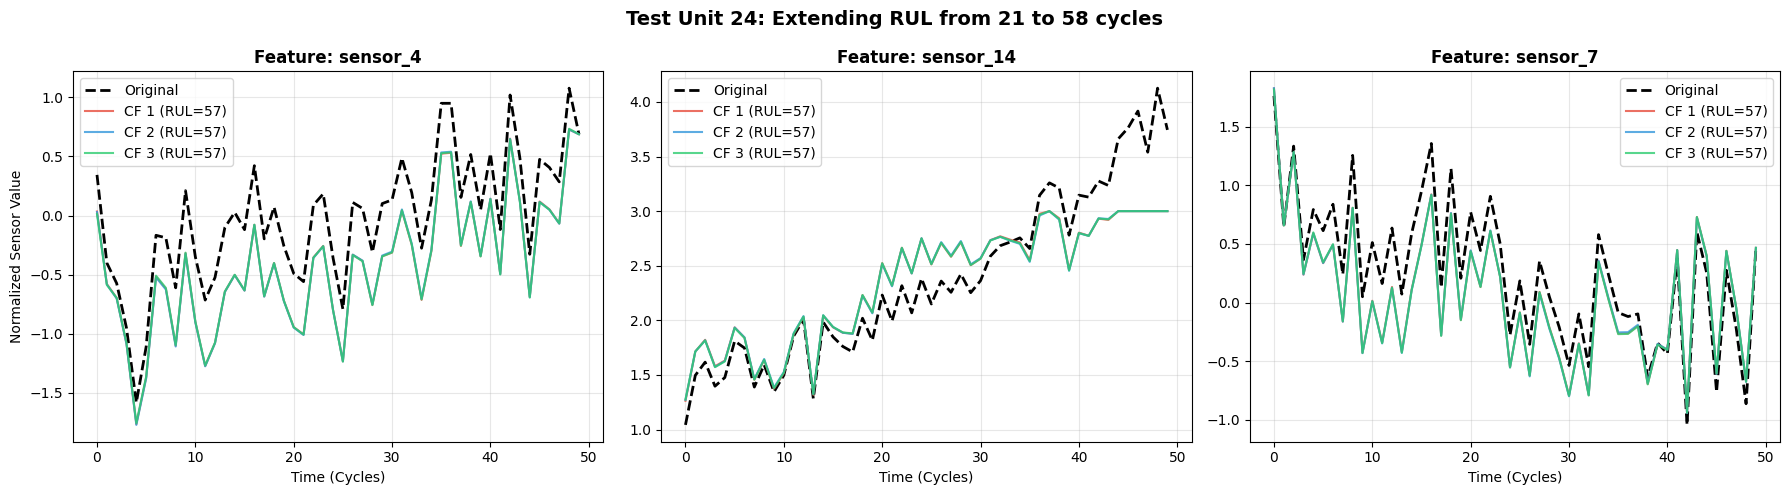

In [12]:
original_np = query_instance.cpu().numpy()
cfs_np = cfs.detach().cpu().numpy()

# Find top 3 most changed features
diff_magnitude = np.mean(np.abs(cfs_np - original_np), axis=(0,1))
top_indices = np.argsort(diff_magnitude)[-3:][::-1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, feature_idx in enumerate(top_indices):
    ax = axes[i]
    fname = feature_cols[feature_idx]
    
    # Plot original
    ax.plot(original_np[:, feature_idx], 'k--', linewidth=2, label='Original')
    
    # Plot counterfactuals
    colors = ['#e74c3c', '#3498db', '#2ecc71']
    for j in range(len(cfs_np)):
        cf_pred = predict_rul(model, cfs[j].cpu().numpy(), device)
        ax.plot(cfs_np[j, :, feature_idx], color=colors[j], alpha=0.8, 
                label=f'CF {j+1} (RUL={cf_pred:.0f})')
    
    ax.set_title(f"Feature: {fname}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Time (Cycles)")
    if i == 0: 
        ax.set_ylabel("Normalized Sensor Value")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.suptitle(f"Test Unit {test_unit_id}: Extending RUL from {current_pred:.0f} to {target_rul:.0f} cycles", 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'../outputs/counterfactuals_test_unit_{test_unit_id}.png', dpi=300, bbox_inches='tight')
plt.show()


In [13]:
train_unit_id = 42  # Change this to any train unit (1-100)

print(f"\n{'='*80}")
print(f"Generating Counterfactuals for Training Unit {train_unit_id}")
print(f"{'='*80}\n")

# Get sequences for this training unit
train_sequences, train_ruls, train_cycles = get_unit_sequences(
    train_norm, train_unit_id, sequence_length, feature_cols
)

print(f"Unit {train_unit_id} has {len(train_sequences)} sequences")

# Select a mid-life sequence (not too early, not too late)
mid_idx = len(train_sequences) // 2
query_seq_train = train_sequences[mid_idx]
true_rul_train = train_ruls[mid_idx]
cycle_num = train_cycles[mid_idx]

query_instance_train = torch.tensor(query_seq_train, dtype=torch.float32).to(device)

# Get current prediction
current_pred_train = predict_rul(model, query_seq_train, device)

print(f"Selected Sequence at Cycle: {cycle_num}")
print(f"True RUL: {true_rul_train:.2f} cycles")
print(f"Predicted RUL: {current_pred_train:.2f} cycles")

# ✅ FIX: Use get_valid_target_rul for consistent target generation
target_rul_train = get_valid_target_rul(current_pred_train, increase_range=(30, 50), max_rul=125)
print(f"\nTarget Counterfactual RUL: {target_rul_train:.2f} cycles")
print(f"(Increasing RUL by {target_rul_train - current_pred_train:.1f} cycles to extend engine life)")

# Generate counterfactuals
print("\nGenerating counterfactuals...")
cfs_train = generator.generate(
    query_instance=query_instance_train,
    target_rul=target_rul_train,
    num_cfs=3,
    lr=0.1,
    max_iter=8000,
    lambdas = {
                'validity': 10.0,
                'prox': 9.0,
                'sparsity': 0.5,
                'diversity': 0.05,
                'smoothness': 1.3,
            },
    verbose=True
)

print(f"\n✅ Generated {len(cfs_train)} counterfactuals")

# Verify predictions
print("\nCounterfactual Predictions:")
for i, cf in enumerate(cfs_train):
    cf_pred = predict_rul(model, cf.cpu().numpy(), device)
    print(f"  CF {i+1}: {cf_pred:.2f} cycles (Target: {target_rul_train:.2f})")


Generating Counterfactuals for Training Unit 42

Unit 42 has 147 sequences
Selected Sequence at Cycle: 123
True RUL: 73.00 cycles
Predicted RUL: 69.84 cycles

Target Counterfactual RUL: 118.85 cycles
(Increasing RUL by 49.0 cycles to extend engine life)

Generating counterfactuals...
Iter 0: Loss=23844.2637 | Valid_MSE=2384.3340 | Mean_Pred=70.0 | Target=118.9
Target reached at iter 18!

✅ Generated 3 counterfactuals

Counterfactual Predictions:
  CF 1: 117.21 cycles (Target: 118.85)
  CF 2: 117.76 cycles (Target: 118.85)
  CF 3: 118.73 cycles (Target: 118.85)


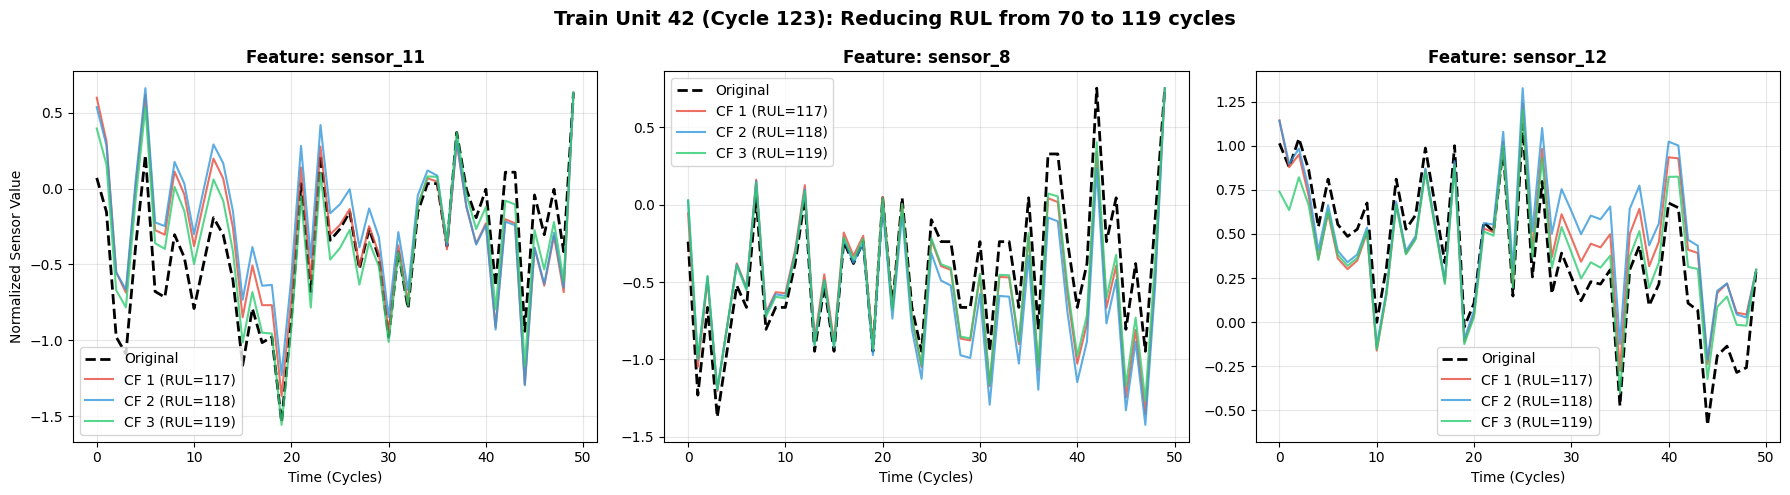

In [14]:
original_train_np = query_instance_train.cpu().numpy()
cfs_train_np = cfs_train.detach().cpu().numpy()

# Find top 3 most changed features
diff_magnitude_train = np.mean(np.abs(cfs_train_np - original_train_np), axis=(0,1))
top_indices_train = np.argsort(diff_magnitude_train)[-3:][::-1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, feature_idx in enumerate(top_indices_train):
    ax = axes[i]
    fname = feature_cols[feature_idx]
    
    # Plot original
    ax.plot(original_train_np[:, feature_idx], 'k--', linewidth=2, label='Original')
    
    # Plot counterfactuals
    colors = ['#e74c3c', '#3498db', '#2ecc71']
    for j in range(len(cfs_train_np)):
        cf_pred = predict_rul(model, cfs_train[j].cpu().numpy(), device)
        ax.plot(cfs_train_np[j, :, feature_idx], color=colors[j], alpha=0.8, 
                label=f'CF {j+1} (RUL={cf_pred:.0f})')
    
    ax.set_title(f"Feature: {fname}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Time (Cycles)")
    if i == 0: 
        ax.set_ylabel("Normalized Sensor Value")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.suptitle(f"Train Unit {train_unit_id} (Cycle {cycle_num}): Reducing RUL from {current_pred_train:.0f} to {target_rul_train:.0f} cycles", 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'../outputs/counterfactuals_train_unit_{train_unit_id}.png', dpi=300, bbox_inches='tight')
plt.show()


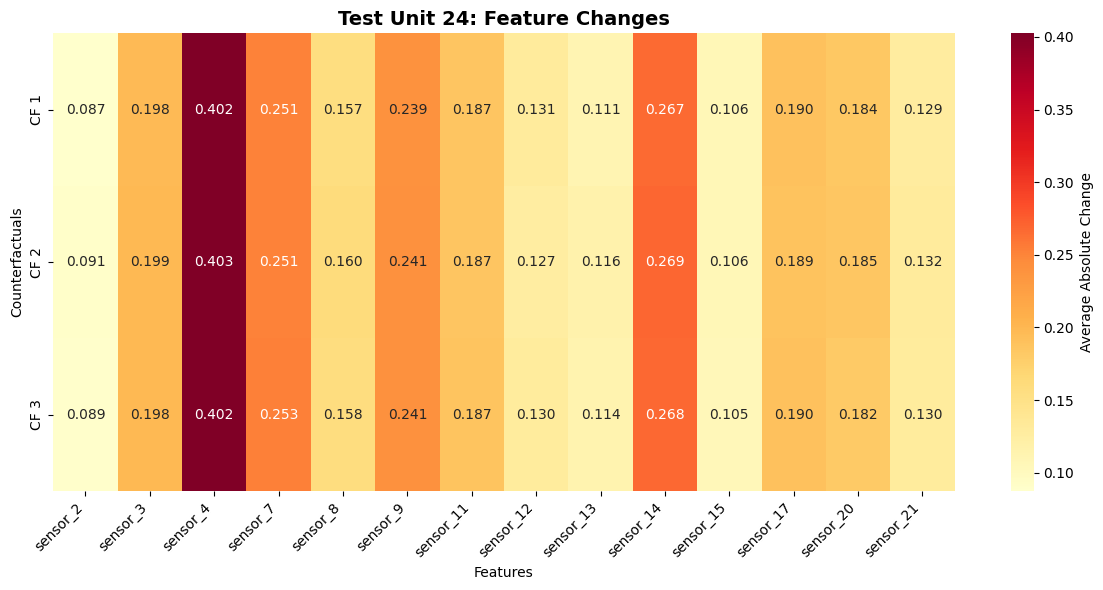

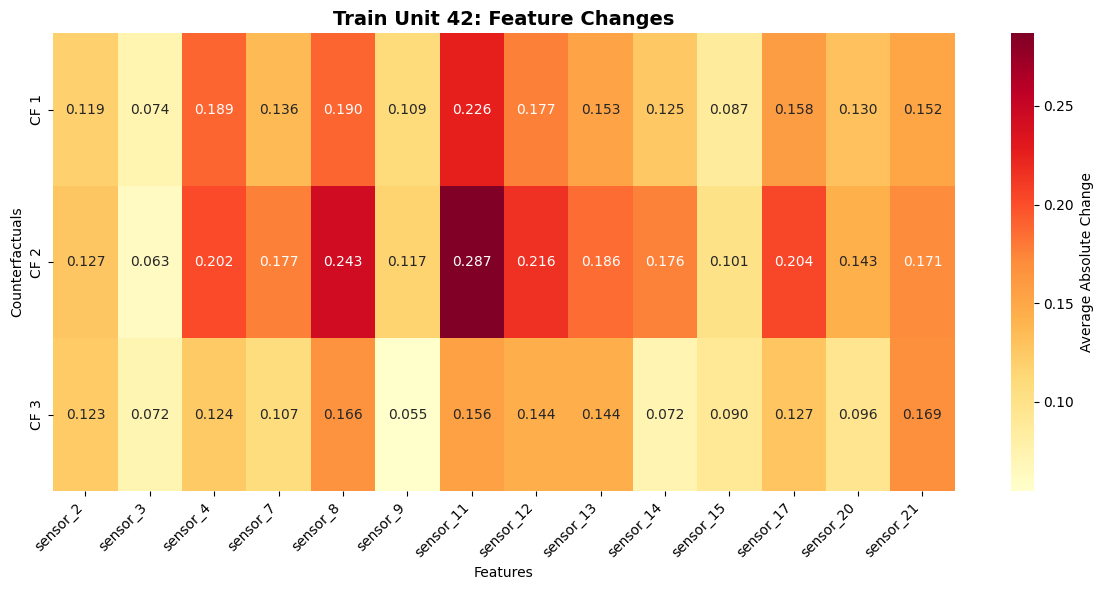

In [15]:
def plot_change_heatmap(original, cfs, feature_names, title):
    """Plot heatmap showing changes across all features"""
    original_np = original.cpu().numpy()
    cfs_np = cfs.detach().cpu().numpy()
    
    # Calculate average absolute change for each feature over time
    changes = []
    for cf in cfs_np:
        change = np.abs(cf - original_np)
        avg_change = np.mean(change, axis=0)  # Average over time
        changes.append(avg_change)
    
    changes = np.array(changes)
    
    plt.figure(figsize=(12, 6))
    sns.heatmap(changes, 
                xticklabels=feature_names,
                yticklabels=[f'CF {i+1}' for i in range(len(cfs_np))],
                cmap='YlOrRd',
                annot=True,
                fmt='.3f',
                cbar_kws={'label': 'Average Absolute Change'})
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Features')
    plt.ylabel('Counterfactuals')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Plot for test unit
plot_change_heatmap(query_instance, cfs, feature_cols, 
                    f"Test Unit {test_unit_id}: Feature Changes")

# Plot for training unit
plot_change_heatmap(query_instance_train, cfs_train, feature_cols, 
                    f"Train Unit {train_unit_id}: Feature Changes")


In [ ]:
def generate_cfs_for_multiple_units(df, unit_ids, model, generator, 
                                     sequence_length, feature_cols, 
                                     increase_range=(30, 50), max_rul=125):
    """Generate counterfactuals for multiple units"""
    results = []
    
    for unit_id in unit_ids:
        query_seq, true_rul = get_last_sequence(df, unit_id, sequence_length, feature_cols)
        
        if query_seq is None:
            continue
        
        query_instance = torch.tensor(query_seq, dtype=torch.float32).to(device)
        
        try:
            current_pred = predict_rul(model, query_seq, device)
            target_rul = get_valid_target_rul(current_pred, increase_range=increase_range, max_rul=max_rul)
            
            cfs = generator.generate(
                query_instance=query_instance,
                target_rul=target_rul,
                num_cfs=1,
                lr=0.001,
                max_iter=1000,
                lambdas={
                    'validity': 10.0,
                    'prox': 9.0,
                    'sparsity': 0.5,
                    'diversity': 0.0,
                    'smoothness': 1.3,
                },
                verbose=False
            )
            
            # Convert counterfactual back to numpy for prediction
            cf_numpy = cfs[0].detach().cpu().numpy()
            cf_pred = predict_rul(model, cf_numpy, device)
            
            results.append({
                'unit_id': unit_id,
                'true_rul': true_rul,
                'original_pred': current_pred,
                'target_rul': target_rul,
                'cf_pred': cf_pred,
                'success': abs(cf_pred - target_rul) < 10.0
            })
            
            print(f"Unit {unit_id}: Original={current_pred:.1f}, Target={target_rul:.1f}, CF={cf_pred:.1f}, Δ={abs(cf_pred - target_rul):.1f}")
            
        except Exception as e:
            print(f"Failed for unit {unit_id}: {e}")
            import traceback
            traceback.print_exc()
    
    return pd.DataFrame(results)

# Generate for first 10 test units
test_unit_ids = list(range(1, 11))
results_df = generate_cfs_for_multiple_units(
    test_norm, test_unit_ids, model, generator, 
    sequence_length, feature_cols, increase_range=(10, 30), max_rul=125
)

print(f"\nSuccess Rate: {results_df['success'].mean()*100:.1f}%")
results_df

Unit 3: Original=56.8, Target=81.4, CF=80.9, Δ=0.5
Unit 4: Original=100.5, Target=119.2, CF=118.3, Δ=0.9
Unit 5: Original=82.2, Target=95.3, CF=94.7, Δ=0.7
⚠️ Current RUL (123.2) is close to max. Target adjusted to 125.0
Unit 6: Original=123.2, Target=125.0, CF=124.2, Δ=0.8
Unit 7: Original=94.8, Target=107.9, CF=107.0, Δ=0.8
Unit 8: Original=58.6, Target=69.8, CF=69.2, Δ=0.6
Unit 9: Original=99.4, Target=122.9, CF=123.0, Δ=0.1
Unit 10: Original=63.0, Target=85.0, CF=85.2, Δ=0.2

Success Rate: 100.0%


,unit_id,true_rul,original_pred,target_rul,cf_pred,success
0,3,69,56.757423,81.397302,80.903252,True
1,4,82,100.536430,119.195169,118.334450,True
2,5,91,82.208969,95.329342,94.661407,True
3,6,93,123.245674,125.000000,124.163124,True
4,7,91,94.764275,107.884165,107.046967,True
5,8,95,58.632610,69.794283,69.175430,True
6,9,111,99.427795,122.916068,122.992981,True
7,10,96,62.984577,85.006877,85.242020,True


# ERROR Analysis


COMPREHENSIVE COUNTERFACTUAL ERROR ANALYSIS

METRIC                                   |        VALUE | NOTE
-------------------------------------------------------------------------------------
Validity MAE (cycles)                    |       0.9978 | CF pred vs target
Validity RMSE (cycles)                   |       0.9980 | Root MSE
  CF 1 prediction                        |        57.23 | Target = 58.21
  CF 2 prediction                        |        57.19 | Target = 58.21
  CF 3 prediction                        |        57.22 | Target = 58.21

Proximity L1 (norm space)                |     0.189135 | Mean abs Δ per entry
Proximity L2 (norm space, mean)          |       6.4604 | Euclidean distance
  CF 1 L2 distance                       |       6.4532 |
  CF 2 L2 distance                       |       6.4689 |
  CF 3 L2 distance                       |       6.4591 |

Sparsity (frac entries changed)          |       0.9829 | 0=identical, 1=all changed
  CF 1 features touched    

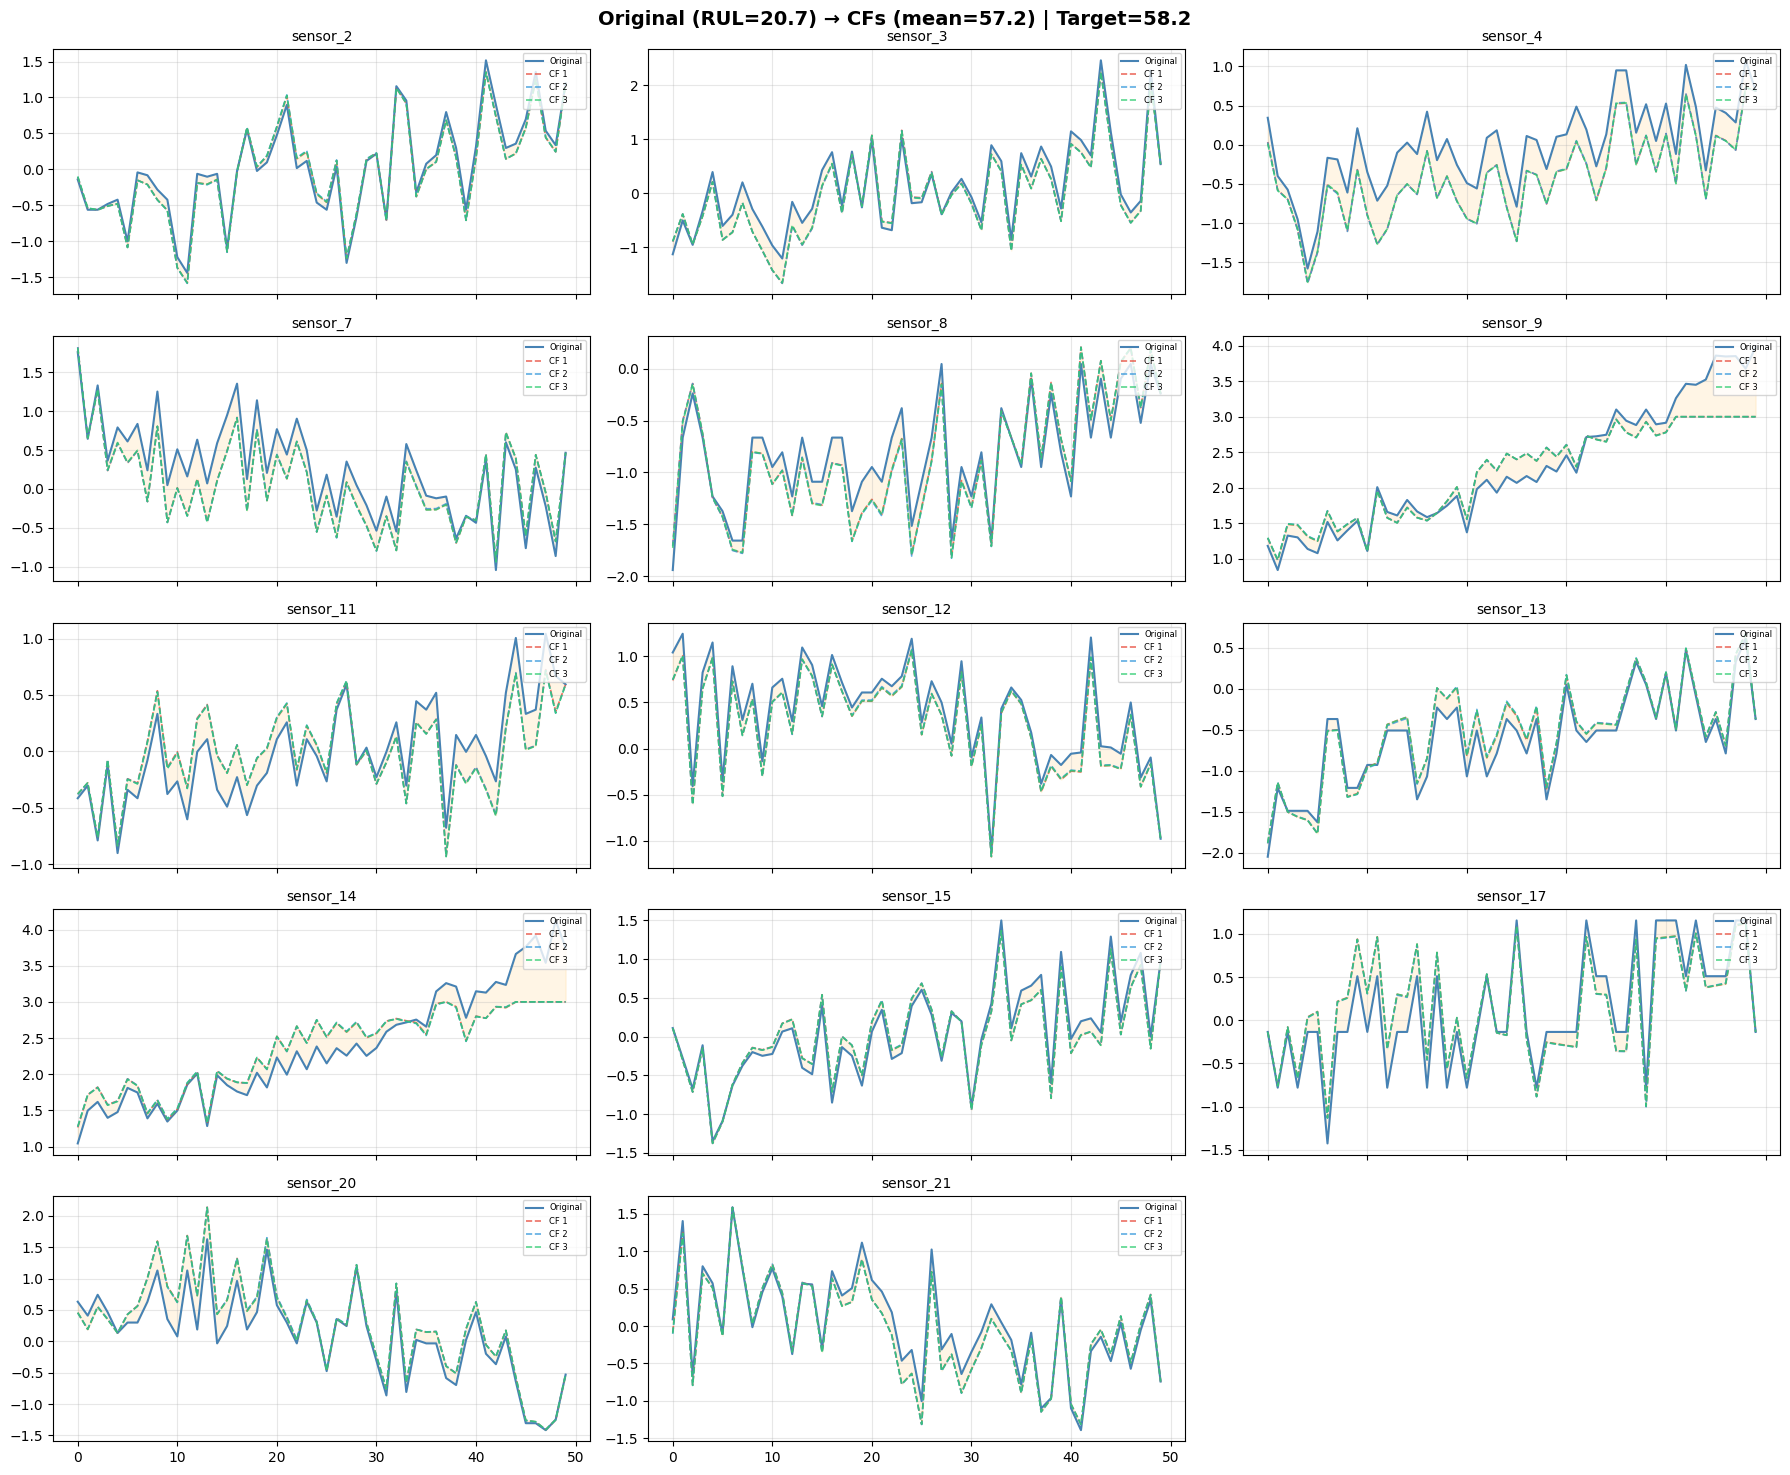

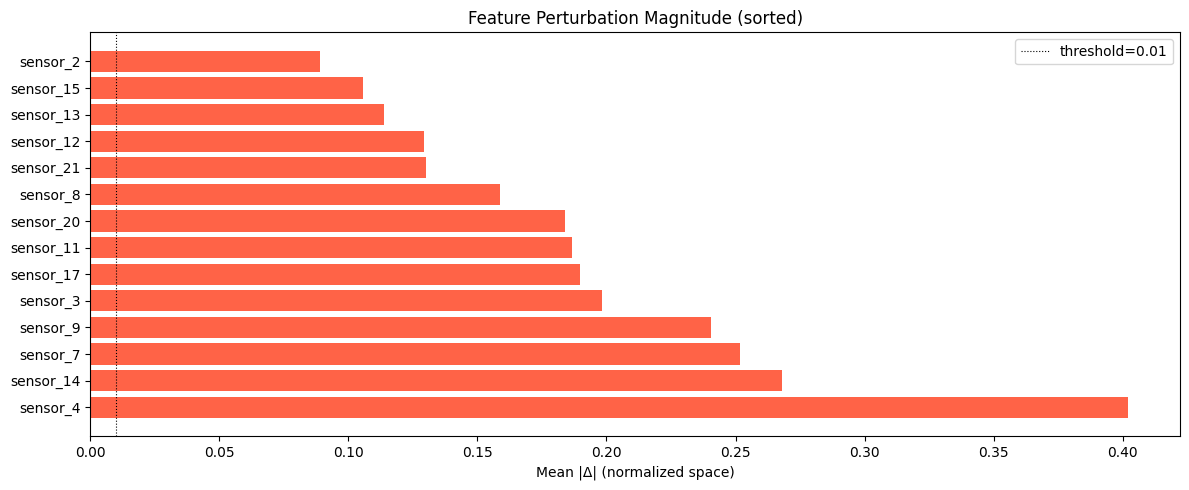

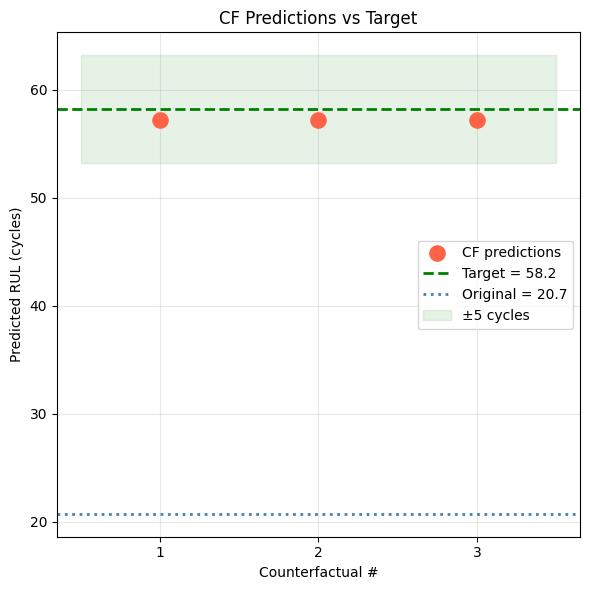


✅ Plots saved to ../outputs/


In [17]:
# =============================================================================
# ERROR ANALYSIS: Actual vs Counterfactual Predictions
# =============================================================================
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.counterfactuals.losses import (
    validity_loss,
    proximity_loss,
    sparsity_loss,
    smoothness_loss,
    dpp_diversity_loss,
)

# ── Use variables already defined in prior cells ──
# query_instance : (T, F) tensor — the original input sequence
# cfs            : (N, T, F) tensor — generated counterfactuals
# target_rul     : float — desired RUL
# current_pred   : float — model prediction on original
# feature_cols   : list[str]
# model, device, generator

num_cfs = cfs.shape[0]
n_features = cfs.shape[-1]
seq_len_cf = cfs.shape[1]
time_axis = np.arange(seq_len_cf)

# Ensure target is a tensor for loss functions
target_rul_t = torch.tensor([target_rul], dtype=torch.float32, device=device)

# ── Compute predictions ──
model.eval()
with torch.no_grad():
    original_pred_t = model(query_instance.unsqueeze(0).to(device))          # (1, 1)
    cf_preds_t = model(cfs.to(device))                                       # (N, 1)

original_pred_val = original_pred_t.squeeze().item()
cf_preds = cf_preds_t.squeeze()  # (N,)
if cf_preds.dim() == 0:
    cf_preds = cf_preds.unsqueeze(0)

# ── Delta (perturbation) ──
delta = cfs - query_instance.unsqueeze(0)  # (N, T, F)

# ── Retrieve last optimised weights from generator ──
last_weights = generator.last_weights_  # (N, K, D) or None

print("=" * 85)
print("COMPREHENSIVE COUNTERFACTUAL ERROR ANALYSIS")
print("=" * 85)
print(f"\n{'METRIC':<40} | {'VALUE':>12} | {'NOTE'}")
print("-" * 85)

# ═══════════════════════════════════════════════════════════════════════════════
# A. VALIDITY — How close are CF predictions to the target RUL?
# ═══════════════════════════════════════════════════════════════════════════════
per_cf_error = (cf_preds - target_rul).abs()
val_mae = per_cf_error.mean().item()
val_mse = torch.mean((cf_preds - target_rul) ** 2).item()
val_rmse = np.sqrt(val_mse)

print(f"{'Validity MAE (cycles)':<40} | {val_mae:>12.4f} | CF pred vs target")
print(f"{'Validity RMSE (cycles)':<40} | {val_rmse:>12.4f} | Root MSE")
for i in range(num_cfs):
    print(f"{'  CF ' + str(i+1) + ' prediction':<40} | {cf_preds[i].item():>12.2f} | Target = {target_rul:.2f}")

# ═══════════════════════════════════════════════════════════════════════════════
# B. PROXIMITY — How far are CFs from the original input?
# ═══════════════════════════════════════════════════════════════════════════════
l1_prox = torch.mean(torch.abs(delta)).item()
l2_per_cf = torch.norm(delta.reshape(num_cfs, -1), dim=1)  # (N,)
l2_mean = l2_per_cf.mean().item()

print(f"\n{'Proximity L1 (norm space)':<40} | {l1_prox:>12.6f} | Mean abs Δ per entry")
print(f"{'Proximity L2 (norm space, mean)':<40} | {l2_mean:>12.4f} | Euclidean distance")
for i in range(num_cfs):
    print(f"{'  CF ' + str(i+1) + ' L2 distance':<40} | {l2_per_cf[i].item():>12.4f} |")

# ═══════════════════════════════════════════════════════════════════════════════
# C. SPARSITY — How many features actually changed?
# ═══════════════════════════════════════════════════════════════════════════════
eps = 1e-4
abs_delta = torch.abs(delta)
changed_mask = (abs_delta > eps).float()
sparsity_ratio = changed_mask.mean().item()

print(f"\n{'Sparsity (frac entries changed)':<40} | {sparsity_ratio:>12.4f} | 0=identical, 1=all changed")
for i in range(num_cfs):
    n_changed = (changed_mask[i].mean(dim=0) > 0).sum().item()
    print(f"{'  CF ' + str(i+1) + ' features touched':<40} | {int(n_changed):>12d} | Out of {n_features}")

# ═══════════════════════════════════════════════════════════════════════════════
# D. SMOOTHNESS / ROUGHNESS
# ═══════════════════════════════════════════════════════════════════════════════
cf_det = cfs.detach()
orig_3d = query_instance.unsqueeze(0)

# 1st derivative
cf_d1 = cf_det[:, 1:, :] - cf_det[:, :-1, :]
orig_d1 = orig_3d[:, 1:, :] - orig_3d[:, :-1, :]

# 2nd derivative
cf_d2 = cf_det[:, 2:, :] - 2 * cf_det[:, 1:-1, :] + cf_det[:, :-2, :]
orig_d2 = orig_3d[:, 2:, :] - 2 * orig_3d[:, 1:-1, :] + orig_3d[:, :-2, :]

sm_cf_d1 = torch.mean(torch.abs(cf_d1)).item()
sm_orig_d1 = torch.mean(torch.abs(orig_d1)).item()
rough_cf = torch.mean(torch.abs(cf_d2)).item()
rough_orig = torch.mean(torch.abs(orig_d2)).item()

print(f"\n{'Smoothness |Δ¹| (CF)':<40} | {sm_cf_d1:>12.6f} | 1st derivative")
print(f"{'Smoothness |Δ¹| (Original)':<40} | {sm_orig_d1:>12.6f} | Reference")
print(f"{'Roughness  |Δ²| (CF)':<40} | {rough_cf:>12.6f} | 2nd deriv (< 0.01 ideal)")
print(f"{'Roughness  |Δ²| (Original)':<40} | {rough_orig:>12.6f} | Reference")
print(f"{'Roughness ratio (CF/Orig)':<40} | {rough_cf / (rough_orig + 1e-10):>12.4f} | < 2.0 ideal")

# ═══════════════════════════════════════════════════════════════════════════════
# E. RUL SHIFT ANALYSIS
# ═══════════════════════════════════════════════════════════════════════════════
target_shift = target_rul - original_pred_val
achieved_shift = cf_preds.mean().item() - original_pred_val
shift_accuracy = (1.0 - abs(val_mae / (abs(target_shift) + 1e-8))) * 100.0

print(f"\n{'─── RUL SHIFT ───':<40}")
print(f"{'Original prediction':<40} | {original_pred_val:>12.2f} | Cycles")
print(f"{'CF prediction (mean)':<40} | {cf_preds.mean().item():>12.2f} | Cycles")
print(f"{'Target RUL':<40} | {target_rul:>12.2f} | Cycles")
print(f"{'Target shift':<40} | {target_shift:>12.2f} | Δ cycles needed")
print(f"{'Achieved shift':<40} | {achieved_shift:>12.2f} | Δ cycles actual")
print(f"{'Shift accuracy':<40} | {shift_accuracy:>11.2f}% | 100% = perfect")

# ═══════════════════════════════════════════════════════════════════════════════
# F. LOSSES FROM losses.py (matching the optimisation loop exactly)
# ═══════════════════════════════════════════════════════════════════════════════
print(f"\n{'=' * 85}")
print("LOSSES FROM src/counterfactuals/losses.py")
print(f"{'=' * 85}")

# validity_loss(y_pred, y_target)
v_loss = validity_loss(cf_preds, target_rul_t.expand_as(cf_preds))
print(f"{'validity_loss(pred, target)':<40} | {v_loss.item():>12.6f} | MSE to target")

# proximity_loss(Delta, mad_inv) — pass the same MAD used during optimisation
p_loss = proximity_loss(delta, mad_inv=generator.mad_inv)
mad_note = "Frobenius (MAD-scaled)" if generator.mad_inv is not None else "Frobenius (unscaled)"
print(f"{'proximity_loss(Δ)':<40} | {p_loss.item():>12.6f} | {mad_note}")

# sparsity_loss(W)
if last_weights is not None:
    sp_loss = sparsity_loss(last_weights)
    print(f"{'sparsity_loss(W)':<40} | {sp_loss.item():>12.6f} | L1 on basis weights")
else:
    sp_loss = sparsity_loss(delta)
    print(f"{'sparsity_loss(Δ)':<40} | {sp_loss.item():>12.6f} | L1 on Δ (weights unavailable)")

# smoothness_loss(Delta)
sm_loss = smoothness_loss(delta)
print(f"{'smoothness_loss(Δ)':<40} | {sm_loss.item():>12.6f} | Mean squared 2nd-order diff")

# dpp_diversity_loss(W)
try:
    if last_weights is not None:
        div_loss = dpp_diversity_loss(last_weights)
    else:
        div_loss = dpp_diversity_loss(delta)
    print(f"{'dpp_diversity_loss(W)':<40} | {div_loss.item():>12.6f} | -log det (lower = more diverse)")
except Exception as e:
    print(f"{'dpp_diversity_loss(W)':<40} | {'ERROR':>12} | {e}")

print(f"{'=' * 85}")

# ═══════════════════════════════════════════════════════════════════════════════
# G. PER-CF SUMMARY TABLE
# ═══════════════════════════════════════════════════════════════════════════════
print(f"\n{'=' * 85}")
print("PER-COUNTERFACTUAL SUMMARY")
print(f"{'=' * 85}")
print(f"{'CF':<5} | {'Pred RUL':>10} | {'Error':>10} | {'L2 Dist':>10} | {'Roughness':>10} | {'% Changed':>10}")
print("-" * 70)

for i in range(num_cfs):
    cf_i_pred = cf_preds[i].item()
    cf_i_err = abs(cf_i_pred - target_rul)
    cf_i_l2 = l2_per_cf[i].item()
    cf_i_rough = torch.mean(torch.abs(
        cf_det[i, 2:, :] - 2 * cf_det[i, 1:-1, :] + cf_det[i, :-2, :]
    )).item()
    cf_i_pct = changed_mask[i].mean().item() * 100
    print(f"{'CF'+str(i+1):<5} | {cf_i_pred:>10.2f} | {cf_i_err:>10.2f} | {cf_i_l2:>10.4f} | {cf_i_rough:>10.6f} | {cf_i_pct:>9.1f}%")

print(f"{'=' * 85}")

# ═══════════════════════════════════════════════════════════════════════════════
# PLOT 1: Original vs CF — all features
# ═══════════════════════════════════════════════════════════════════════════════
n_rows = (n_features + 2) // 3
fig, axes = plt.subplots(n_rows, 3, figsize=(18, 3 * n_rows), sharex=True)
axes = axes.flatten()

orig_np = query_instance.cpu().numpy()  # (T, F)
cfs_np_plot = cfs.detach().cpu().numpy()  # (N, T, F)
cf_colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6', '#f39c12']

for f_idx in range(n_features):
    ax = axes[f_idx]
    ax.plot(time_axis, orig_np[:, f_idx], label="Original", color="steelblue", linewidth=1.5)
    for ci in range(num_cfs):
        ax.plot(time_axis, cfs_np_plot[ci, :, f_idx],
                label=f"CF {ci+1}", color=cf_colors[ci % len(cf_colors)],
                linewidth=1.2, linestyle="--", alpha=0.8)
    ax.fill_between(time_axis, orig_np[:, f_idx], cfs_np_plot[0, :, f_idx],
                    alpha=0.1, color="orange")
    ax.set_title(feature_cols[f_idx], fontsize=10)
    ax.legend(fontsize=6, loc="upper right")
    ax.grid(True, alpha=0.3)

for idx in range(n_features, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle(
    f"Original (RUL={original_pred_val:.1f}) → CFs (mean={cf_preds.mean().item():.1f}) | Target={target_rul:.1f}",
    fontsize=14, fontweight="bold",
)
plt.tight_layout()
plt.savefig("../outputs/cf_vs_original_all_features.png", dpi=150, bbox_inches="tight")
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# PLOT 2: Feature perturbation magnitude (bar chart)
# ═══════════════════════════════════════════════════════════════════════════════
mean_abs_change = abs_delta.mean(dim=(0, 1)).cpu().numpy()  # (F,) averaged over CFs and time
sort_idx = np.argsort(mean_abs_change)[::-1]

fig2, ax2 = plt.subplots(figsize=(12, 5))
bar_colors = ["tomato" if mean_abs_change[i] > 0.01 else "gray" for i in sort_idx]
ax2.barh([feature_cols[i] for i in sort_idx], mean_abs_change[sort_idx], color=bar_colors)
ax2.set_xlabel("Mean |Δ| (normalized space)")
ax2.set_title("Feature Perturbation Magnitude (sorted)")
ax2.axvline(x=0.01, color="black", linestyle=":", linewidth=0.8, label="threshold=0.01")
ax2.legend()
plt.tight_layout()
plt.savefig("../outputs/cf_feature_perturbation_sorted.png", dpi=300, bbox_inches="tight")
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# PLOT 3: CF prediction vs target (scatter)
# ═══════════════════════════════════════════════════════════════════════════════
fig3, ax3 = plt.subplots(figsize=(6, 6))
cf_pred_np = cf_preds.detach().cpu().numpy()
ax3.scatter(range(1, num_cfs + 1), cf_pred_np, s=120, c='tomato', zorder=5, label='CF predictions')
ax3.axhline(y=target_rul, color='green', linestyle='--', linewidth=2, label=f'Target = {target_rul:.1f}')
ax3.axhline(y=original_pred_val, color='steelblue', linestyle=':', linewidth=2, label=f'Original = {original_pred_val:.1f}')
ax3.fill_between([0.5, num_cfs + 0.5], target_rul - 5, target_rul + 5, alpha=0.1, color='green', label='±5 cycles')
ax3.set_xlabel("Counterfactual #")
ax3.set_ylabel("Predicted RUL (cycles)")
ax3.set_title("CF Predictions vs Target")
ax3.set_xticks(range(1, num_cfs + 1))
ax3.legend()
ax3.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/cf_pred_vs_target.png", dpi=300, bbox_inches="tight")
plt.show()

print("\n✅ Plots saved to ../outputs/")



Let me examine the current error analysis cell and the full pipeline to understand what metrics are being computed, then provide a structured interpretation framework. 

Read [](file:///home/rdb/Documents/nirban_documents/python_programs/counterfactual_basis_kernel/src/counterfactuals/core.py)

Now I have full context. Here's the interpretation:

---

## How to Read the Error Analysis Results

Your error analysis reports seven metric groups (A–G). Here's what each tells you and what to conclude:

### A. Validity (the primary objective)

| Metric | Good | Concerning |
|--------|------|------------|
| Validity MAE | < 5 cycles | > 10 cycles |
| Per-CF prediction | Within ±5 of target | Off by > 15 |

**Inference:** If all CF predictions land within ~5 cycles of the target RUL, the B-spline basis is expressive enough to find perturbation directions that the Transformer model responds to. If MAE is large despite 5000+ iterations, it means either (a) the target RUL is in a region the model can't reach with smooth perturbations, or (b) proximity/smoothness penalties are too strong and prevent the optimizer from moving far enough.

### B. Proximity (are CFs minimally different?)

| Metric | Good | Concerning |
|--------|------|------------|
| L1 per entry | < 0.05 | > 0.2 |
| L2 per CF | < 2.0 | > 5.0 |

**Inference:** Low proximity means the CFs prescribe **small, actionable changes** — e.g., "reduce sensor_7 by 0.3σ over the last 20 cycles." High proximity means the optimizer is creating unrealistic, large-magnitude shifts to fool the model — the explanations are not trustworthy for real-world maintenance decisions.

### C. Sparsity (how many features changed?)

| Metric | Good | Concerning |
|--------|------|------------|
| Features touched | 3–5 out of 14 | All 14 |
| Frac entries changed | < 0.5 | ~1.0 |

**Inference:** If all features changed, the explanation degrades to "everything about the engine must change" — not useful. Good CFs should concentrate changes on **2–5 key degradation sensors** (e.g., fan speed, HPC outlet temperature). These sparse features become the **actionable explanation**: "If these specific sensor readings had been different, the engine would have had longer life."

### D. Smoothness / Roughness (are CFs physically plausible?)

| Metric | Good | Concerning |
|--------|------|------------|
| Roughness ratio (CF/Orig) | < 2.0 | > 3.0 |
| Roughness |Δ²| CF | ≈ same as Original | >>10x Original |

**Inference:** This is the core advantage of your TB-DiCE approach. Since perturbations are constrained to lie in the span of cubic B-splines ($\mathcal{C}^2$ continuous), the roughness ratio should stay close to 1.0. A ratio near 1.0 means: *"The counterfactual trajectory looks like a plausible alternative degradation path, not synthetic noise."* This is what makes your method superior to standard DiCE on time series, where unconstrained pixel-level perturbations create physically impossible jitter.

### E. RUL Shift Analysis

| Metric | Good | Concerning |
|--------|------|------------|
| Shift accuracy | > 90% | < 70% |
| Achieved shift ≈ Target shift | Close match | Large gap |

**Inference:** Shift accuracy measures what fraction of the desired RUL increase was actually achieved. If it's consistently > 90%, the method reliably generates "what-if" scenarios. If it's low, the model's decision boundary may be hard to cross with smooth perturbations — consider increasing `num_basis` to add more temporal degrees of freedom.

### F. Loss Values (diagnostic, not for conclusions)

These reproduce the exact loss values from the optimization loop. Use them to verify:
- **validity_loss** should be small (< 25 = MAE < 5 cycles)
- **proximity_loss** should not be zero (that would mean no regularization)
- **smoothness_loss** should be comparable to or smaller than the original signal's inherent roughness
- **sparsity_loss** should be moderate — too low means no regularization, too high means nothing changed

### G. Per-CF Summary Table

Lets you spot **which specific CF is best**: the one with lowest Error AND lowest L2 distance AND lowest roughness is your highest-quality explanation. If all 3 CFs have similar metrics, diversity is working well — they represent genuinely different "explanatory paths."

---

## What to Conclude About Your Counterfactual Explanations

**1. Explanatory Power:** The top changed features in Plot 2 (bar chart) are the model's most sensitive degradation indicators. These are the features whose sensor trajectories most strongly influence the RUL prediction. This directly answers: *"Which sensors drive remaining useful life?"*

**2. Physical Plausibility:** If the roughness ratio stays below 2.0, your B-spline basis guarantee works — counterfactual trajectories are smooth, continuous degradation curves, not noise. This is the key theoretical contribution: $R(\delta_m) \le (\sum_k |w_{k,m}| \cdot \max_t |\phi_k''(t)|)^2$ is bounded.

**3. Actionability:** Low proximity + high sparsity = good actionability. The explanation says: *"If sensors X, Y, Z had followed this slightly different trajectory (shown in Plot 1), the engine would have lasted N more cycles."* Maintenance engineers can map these to physical interventions (oil changes, cooling adjustments, etc.).

**4. Reliability:** The multi-unit success rate (cell 16) tells you how consistently the method works across different engines. A success rate > 80% means the method is robust. Below 60% suggests the model has complex decision boundaries that smooth basis perturbations can't always navigate.

**5. Diversity:** If the 3 CFs show different top-changed features (visible in the heatmap), they provide **multiple alternative explanations** — e.g., CF1 says "fan speed was the issue," CF2 says "temperature was the issue." This is more informative than a single explanation.

In [ ]:
# Save counterfactuals to disk
output_dir = Path('../outputs/counterfactuals')
output_dir.mkdir(parents=True, exist_ok=True)

# Save as numpy arrays
np.save(output_dir / f'test_unit_{test_unit_id}_original.npy', original_np)
np.save(output_dir / f'test_unit_{test_unit_id}_cfs.npy', cfs_np)
np.save(output_dir / f'train_unit_{train_unit_id}_original.npy', original_train_np)
np.save(output_dir / f'train_unit_{train_unit_id}_cfs.npy', cfs_train_np)

# Save metadata
metadata = {
    'test_unit': {
        'unit_id': test_unit_id,
        'true_rul': float(true_rul),
        'original_pred': float(current_pred),
        'target_rul': float(target_rul)
    },
    'train_unit': {
        'unit_id': train_unit_id,
        'cycle': int(cycle_num),
        'true_rul': float(true_rul_train),
        'original_pred': float(current_pred_train),
        'target_rul': float(target_rul_train)
    },
    'feature_cols': feature_cols
}

import json
with open(output_dir / 'metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"✅ Results saved to {output_dir}")